# Member 2 — Regression Models, Evaluation, Tuning, CV, Diagnostics

Input: preprocessed train/test split from Member 1 (`data/processed/regression_train.csv`, `regression_test.csv`).
Scope: 10 regression algorithms, comparison table, GridSearchCV on 2 best models, 5-fold CV, residual/pred-vs-actual
and feature-importance diagnostics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8')
sns.set_palette('tab10')

## 1. Load preprocessed split (owned by Member 1)

Dataset: `data/airquality/AirQualityUCI.csv` (UCI Air Quality). Target: `CO(GT)` — this is the target
Member 1's EDA/preprocessing notebook settled on (`NMHC(GT)` dropped for ~90% missingness; `CO(GT)`
chosen over `C6H6(GT)` after the dataset audit). `-200` is the dataset's missing-value sentinel.

Tries Member 1's cleaned/split CSVs first; falls back to a raw loader with a placeholder impute so this
notebook is not blocked on their output landing.

In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split

TARGET = 'CO(GT)'
PROCESSED_TRAIN = Path('../data/processed/regression_train.csv')
PROCESSED_TEST = Path('../data/processed/regression_test.csv')

if PROCESSED_TRAIN.exists() and PROCESSED_TEST.exists():
    train_df = pd.read_csv(PROCESSED_TRAIN)
    test_df = pd.read_csv(PROCESSED_TEST)
else:
    print('data/processed split not found — using raw-loader fallback')
    raw = pd.read_csv('../data/raw/airquality/AirQualityUCI.csv', sep=';', decimal=',')
    raw = raw.loc[:, ~raw.columns.str.contains('^Unnamed')].dropna(how='all')
    raw = raw.drop(columns=['Date', 'Time', 'NMHC(GT)'])  # NMHC(GT) ~90% missing, unusable
    raw = raw.replace(-200, np.nan)
    raw = raw.dropna(subset=[TARGET])  # can't train/eval without target
    raw = raw.fillna(raw.median(numeric_only=True))  # placeholder impute; Member 1 owns final strategy
    train_df, test_df = train_test_split(raw, test_size=0.2, random_state=RANDOM_STATE)

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]
X_train.shape, X_test.shape

((6139, 15), (1535, 15))

## 2. Define all 10 models

Built up incrementally, one algorithm family per commit.

In [3]:
models = {}

In [4]:
models.update({
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=RANDOM_STATE),
    'ElasticNet Regression': ElasticNet(random_state=RANDOM_STATE),
})
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression']

In [5]:
models['Polynomial Regression'] = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lin', LinearRegression())
])
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression']

In [6]:
models['Decision Tree Regressor'] = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor']

In [7]:
models['Random Forest Regressor'] = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor']

In [8]:
models['Gradient Boosting Regressor'] = GradientBoostingRegressor(random_state=RANDOM_STATE)
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor']

In [9]:
models['SVR'] = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(C=1.0, kernel='rbf'))
])
list(models.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor',
 'SVR']

In [10]:
models['KNN Regressor'] = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])
len(models)

10

## 3. Train all models, generate predictions

In [11]:
predictions = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    fitted_models[name] = model

list(predictions.keys())

['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'ElasticNet Regression',
 'Polynomial Regression',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'Gradient Boosting Regressor',
 'SVR',
 'KNN Regressor']

## 4. Comparison table — R2, RMSE, MAE, ranked

In [12]:
rows = []
for name, y_pred in predictions.items():
    rows.append({
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
    })

results_df = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.937911,0.363235,0.235672
1,Gradient Boosting Regressor,0.931587,0.381284,0.250545
2,KNN Regressor,0.925922,0.396759,0.265355
3,SVR,0.924288,0.401109,0.233616
4,Polynomial Regression,0.918110,0.417153,0.272038
5,Decision Tree Regressor,0.879650,0.505713,0.352119
6,Ridge Regression,0.866914,0.531799,0.339888
7,Linear Regression,0.866912,0.531803,0.339927
8,ElasticNet Regression,0.636083,0.879391,0.622397
9,Lasso Regression,0.304929,1.215334,0.919879


## 5. Hyperparameter tuning — GridSearchCV on top 2 models

In [13]:
top2 = results_df['Model'].head(2).tolist()
print('Tuning:', top2)

param_grids = {
    'Random Forest Regressor': {
        'n_estimators': [100, 200, 400],
        'max_depth': [None, 5, 10, 20],
    },
    'Gradient Boosting Regressor': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4],
    },
    'SVR': {
        'svr__C': [0.1, 1, 10],
        'svr__kernel': ['rbf', 'linear'],
    },
    'KNN Regressor': {
        'knn__n_neighbors': [3, 5, 7, 9, 11],
    },
    'Ridge Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso Regression': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
    'ElasticNet Regression': {'alpha': [0.01, 0.1, 1], 'l1_ratio': [0.1, 0.5, 0.9]},
    'Decision Tree Regressor': {'max_depth': [3, 5, 7, 10, None]},
}

tuned_results = {}
for name in top2:
    grid = param_grids.get(name)
    if grid is None:
        print(f'No grid defined for {name}, skipping tuning')
        continue
    gs = GridSearchCV(models[name], grid, scoring='r2', cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_pred = gs.best_estimator_.predict(X_test)
    tuned_results[name] = {
        'best_params': gs.best_params_,
        'best_cv_r2': gs.best_score_,
        'test_r2_before': results_df.set_index('Model').loc[name, 'R2'],
        'test_r2_after': r2_score(y_test, tuned_pred),
    }
    fitted_models[name] = gs.best_estimator_

pd.DataFrame(tuned_results).T

Tuning: ['Random Forest Regressor', 'Gradient Boosting Regressor']


,best_params,best_cv_r2,test_r2_before,test_r2_after
Random Forest Regressor,"{'max_depth': None, 'n_estimators': 400}",0.927071,0.937911,0.938145
Gradient Boosting Regressor,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.943148,0.931587,0.947154


## 6. 5-fold cross-validated R2 for top 2 models

In [14]:
cv_rows = []
for name in top2:
    scores = cross_val_score(fitted_models[name], X_train, y_train, cv=5, scoring='r2')
    cv_rows.append({'Model': name, 'CV R2 mean': scores.mean(), 'CV R2 std': scores.std()})

pd.DataFrame(cv_rows)

,Model,CV R2 mean,CV R2 std
0,Random Forest Regressor,0.927071,0.005014
1,Gradient Boosting Regressor,0.943148,0.004953


## 7. Diagnostics — residual plot, predicted-vs-actual, feature importance

Best model after tuning: Gradient Boosting Regressor (test R2 = 0.9472)


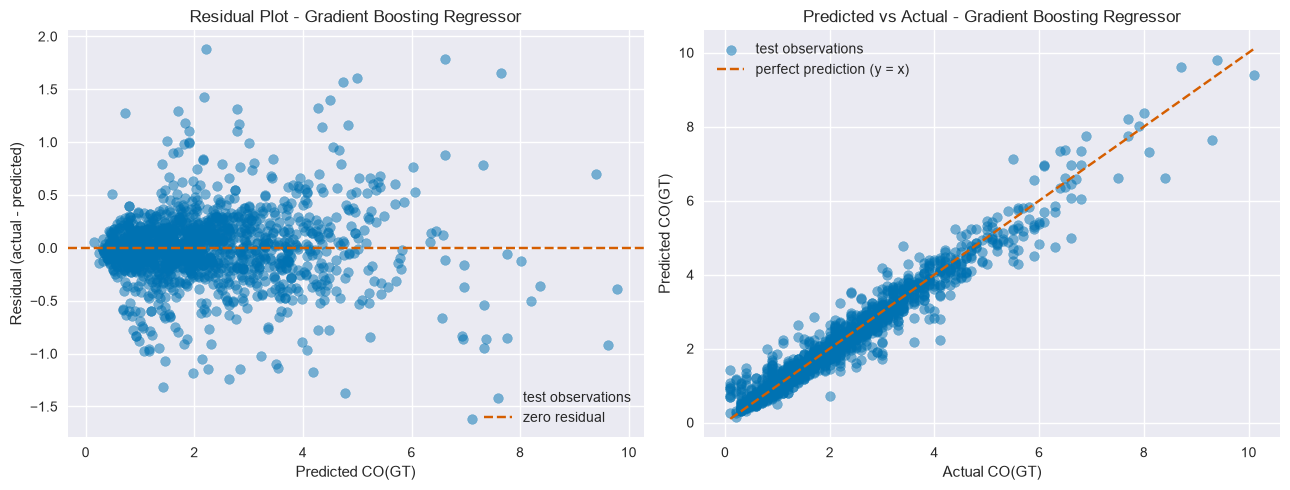

residual mean: 0.0034 | residual std: 0.3352


In [15]:
# best model AFTER tuning (the pre-tuning ranking in section 4 is not the final ranking)
final_r2 = {name: r2_score(y_test, model.predict(X_test)) for name, model in fitted_models.items()}
best_model_name = max(final_r2, key=final_r2.get)
print(f'Best model after tuning: {best_model_name} (test R2 = {final_r2[best_model_name]:.4f})')

best_pred = fitted_models[best_model_name].predict(X_test)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_pred, residuals, alpha=0.5, color='#0072B2', label='test observations')
axes[0].axhline(0, color='#D55E00', linestyle='--', label='zero residual')
axes[0].set_xlabel('Predicted CO(GT)')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title(f'Residual Plot - {best_model_name}')
axes[0].legend()

axes[1].scatter(y_test, best_pred, alpha=0.5, color='#0072B2', label='test observations')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, '--', color='#D55E00', label='perfect prediction (y = x)')
axes[1].set_xlabel('Actual CO(GT)')
axes[1].set_ylabel('Predicted CO(GT)')
axes[1].set_title(f'Predicted vs Actual - {best_model_name}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/regression/regression_diagnostics.png', bbox_inches='tight')
plt.show()

print('residual mean: %.4f | residual std: %.4f' % (residuals.mean(), residuals.std()))

**Observation.** After tuning, Gradient Boosting is the best model (test R2 = 0.947), so the diagnostics use it rather than the pre-tuning winner (Random Forest). Residuals are centred on zero (mean 0.003, std 0.335 against a target std of about 1.45) with no curved pattern, so there is no systematic bias.
The spread widens as the predicted CO increases (heteroscedasticity), and the few largest errors are under-predictions of high-CO hours (above about 6), where the training data is sparse. In the predicted-vs-actual plot the points hug the y = x line and only the highest values drift below it.

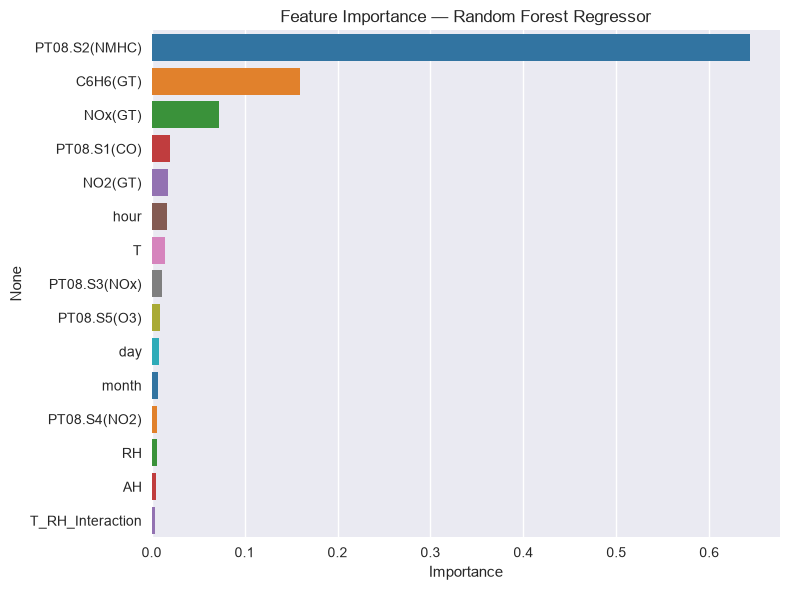

In [16]:
tree_model_name = 'Random Forest Regressor'
tree_model = fitted_models[tree_model_name]
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='tab10', legend=False)
plt.xlabel('Importance')
plt.title(f'Feature Importance — {tree_model_name}')
plt.tight_layout()
plt.savefig('../models/regression/feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Additional analyses from the algorithm notes

The guideline notes ask for more than a single fit per algorithm: tune the regularisation strength (Ridge `alpha`, Lasso `alpha`,
ElasticNet `l1_ratio`), the tree depth, `k` for KNN and `C` / `kernel` for SVR, interpret the linear coefficients, compare polynomial degrees,
show decision-tree feature importance and discuss the impact of scaling on KNN. Sections 5-6 already tuned the two best models
(Random Forest, Gradient Boosting); this section covers the remaining notes. Every search is a 5-fold `GridSearchCV` on the training set
and the test set is only used to report the effect.

### 8.1 Tuning the remaining algorithms

In [17]:
extra_grids = {
    'Ridge Regression': {'alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso Regression': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]},
    'ElasticNet Regression': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1], 'l1_ratio': [0.1, 0.5, 0.9]},
    'Decision Tree Regressor': {'max_depth': [3, 5, 7, 10, 15, None]},
    'KNN Regressor': {'knn__n_neighbors': [3, 5, 7, 9, 11, 15]},
    'SVR': {'svr__C': [0.1, 1, 10], 'svr__kernel': ['rbf', 'linear']},
}
before = results_df.set_index('Model')['R2']

extra_rows, extra_best = [], {}
for name, grid in extra_grids.items():
    gs = GridSearchCV(models[name], grid, scoring='r2', cv=5, n_jobs=-1).fit(X_train, y_train)
    extra_best[name] = gs.best_estimator_
    extra_rows.append({
        'Model': name,
        'best_params': gs.best_params_,
        'best_cv_r2': round(gs.best_score_, 4),
        'test_r2_before': round(before[name], 4),
        'test_r2_after': round(r2_score(y_test, gs.best_estimator_.predict(X_test)), 4),
    })
extra_tuning_df = pd.DataFrame(extra_rows).set_index('Model')
extra_tuning_df

,best_params,best_cv_r2,test_r2_before,test_r2_after
Model,,,,
Ridge Regression,{'alpha': 1},0.8685,0.8669,0.8669
Lasso Regression,{'alpha': 0.0001},0.8685,0.3049,0.8669
ElasticNet Regression,"{'alpha': 0.0001, 'l1_ratio': 0.5}",0.8685,0.6361,0.8669
Decision Tree Regressor,{'max_depth': 7},0.8850,0.8797,0.8967
KNN Regressor,{'knn__n_neighbors': 3},0.9180,0.9259,0.9250
SVR,"{'svr__C': 10, 'svr__kernel': 'rbf'}",0.9369,0.9243,0.9421


**Observation.**
- **Lasso and ElasticNet were crippled by their default penalty.** Test R2 rises from 0.305 to 0.867 (Lasso, `alpha` 1 -> 0.0001) and from 0.636 to 0.867 (ElasticNet). Ridge was already at its best (`alpha = 1`). All three regularised models converge to the plain Linear Regression score (0.867): with 15 features and about 6,000 rows there is almost nothing to regularise, and Lasso at the best `alpha` keeps all 15 features (no coefficient is shrunk to zero).
- **Decision Tree** improves from 0.880 to 0.897 with `max_depth = 7` (the default depth of 5 under-fits).
- **SVR** improves from 0.924 to 0.942 with `C = 10` and the RBF kernel - a gain of +0.018, larger than the tuning gain of Random Forest (+0.0002) or Gradient Boosting (+0.016) in section 5; the linear kernel was worse.
- **KNN** gains nothing: cross-validation prefers `k = 3` but on the test set `k = 5` (0.926) is marginally better than `k = 3` (0.925).

### 8.2 Linear Regression: interpreting the coefficients

Features were standardised by Member 1, so coefficient sizes are directly comparable: each coefficient is the change in `CO(GT)` for a one-standard-deviation increase in that feature, all else equal.

intercept (mean CO(GT) at average feature values): 2.153


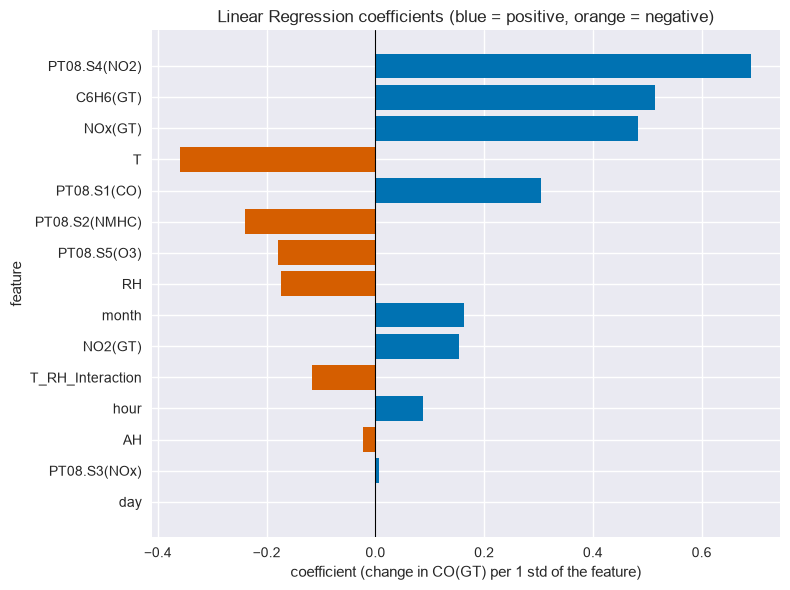

,feature,coefficient
0,PT08.S4(NO2),0.691
1,C6H6(GT),0.515
2,NOx(GT),0.484
3,T,-0.359
4,PT08.S1(CO),0.304
5,PT08.S2(NMHC),-0.240
6,PT08.S5(O3),-0.179
7,RH,-0.174
8,month,0.163
9,NO2(GT),0.154


In [18]:
lin = fitted_models['Linear Regression']
coef_df = (pd.DataFrame({'feature': X_train.columns, 'coefficient': lin.coef_})
           .sort_values('coefficient', key=abs, ascending=False).reset_index(drop=True))
print('intercept (mean CO(GT) at average feature values): %.3f' % lin.intercept_)

plt.figure(figsize=(8, 6))
colors = ['#0072B2' if v >= 0 else '#D55E00' for v in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('coefficient (change in CO(GT) per 1 std of the feature)')
plt.ylabel('feature')
plt.title('Linear Regression coefficients (blue = positive, orange = negative)')
plt.tight_layout()
plt.savefig('../results/regression/linear_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
coef_df.round(3)

**Observation.** The largest positive effects are `PT08.S4(NO2)` (+0.69), `C6H6(GT)` (+0.52) and `NOx(GT)` (+0.48); temperature `T` (-0.36) is the largest negative one. `day`, `PT08.S3(NOx)` and `AH` are about zero, so they add no linear signal.
Caution: `PT08.S2(NMHC)` correlates +0.92 with CO in the EDA yet has a *negative* coefficient (-0.24) here. The sensor columns are strongly correlated with each other (multicollinearity), so individual coefficients describe the effect of a feature *given the others* and should not be read as stand-alone effects.

### 8.3 Polynomial Regression: comparing degrees

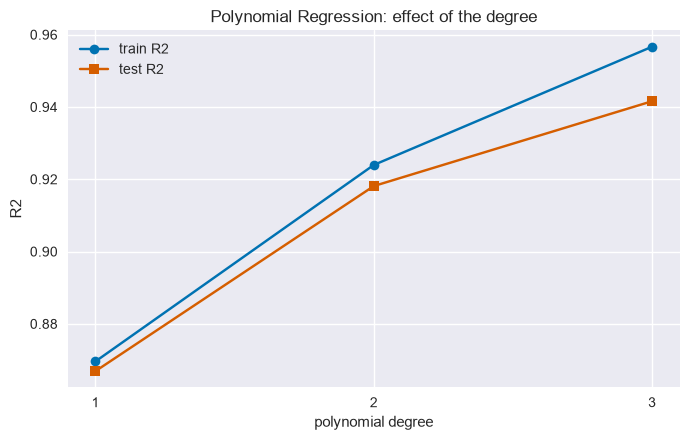

,n_features,train_R2,test_R2,test_RMSE
degree,,,,
1,15,0.8696,0.8669,0.5318
2,135,0.9239,0.9181,0.4172
3,815,0.9567,0.9416,0.3524


In [19]:
poly_rows = []
for degree in [1, 2, 3]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree, include_bias=False)), ('lin', LinearRegression())])
    pipe.fit(X_train, y_train)
    poly_rows.append({
        'degree': degree,
        'n_features': pipe.named_steps['poly'].n_output_features_,
        'train_R2': r2_score(y_train, pipe.predict(X_train)),
        'test_R2': r2_score(y_test, pipe.predict(X_test)),
        'test_RMSE': root_mean_squared_error(y_test, pipe.predict(X_test)),
    })
poly_df = pd.DataFrame(poly_rows).set_index('degree')

plt.figure(figsize=(7, 4.5))
plt.plot(poly_df.index, poly_df['train_R2'], marker='o', color='#0072B2', label='train R2')
plt.plot(poly_df.index, poly_df['test_R2'], marker='s', color='#D55E00', label='test R2')
plt.xticks(poly_df.index)
plt.xlabel('polynomial degree')
plt.ylabel('R2')
plt.title('Polynomial Regression: effect of the degree')
plt.legend()
plt.tight_layout()
plt.savefig('../results/regression/polynomial_degree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
poly_df.round(4)

**Observation.** Test R2 rises with the degree: 0.867 (degree 1, plain linear) -> 0.918 (degree 2, the version in the ranking table) -> 0.942 (degree 3), and RMSE falls from 0.532 to 0.352. The train-test gap also grows (0.007 -> 0.006 -> 0.015) while the number of features explodes (15 -> 135 -> 815), so degree 3 starts to over-fit but still generalises best of the three. It is therefore stronger than the degree-2 model used in section 4, and close to the tuned Gradient Boosting (0.947).

### 8.4 Decision Tree: feature importance (tuned depth)

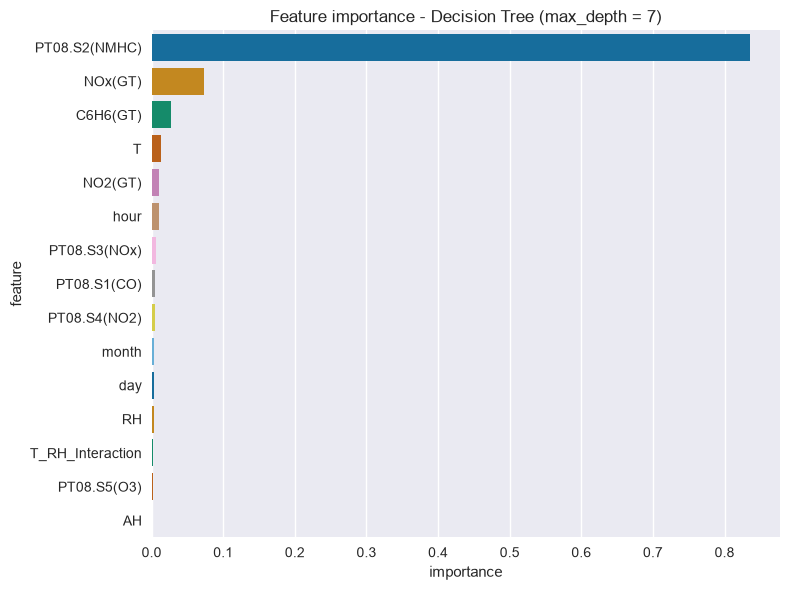

PT08.S2(NMHC)    0.836
NOx(GT)          0.073
C6H6(GT)         0.028
T                0.013
NO2(GT)          0.011
dtype: float64

In [20]:
dt_tuned = extra_best['Decision Tree Regressor']
dt_importance = pd.Series(dt_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=dt_importance.values, y=dt_importance.index, hue=dt_importance.index, palette='colorblind', legend=False)
plt.xlabel('importance')
plt.ylabel('feature')
plt.title(f'Feature importance - Decision Tree (max_depth = {dt_tuned.get_params()["max_depth"]})')
plt.tight_layout()
plt.savefig('../results/regression/decision_tree_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
dt_importance.head(5).round(3)

**Observation.** The tuned tree (`max_depth = 7`) relies almost entirely on one sensor: `PT08.S2(NMHC)` carries 84% of the total importance, followed by `NOx(GT)` (7%) and `C6H6(GT)` (3%). A single tree concentrates importance on its first splits, whereas the Random Forest in section 7 spreads it more widely (0.64 for `PT08.S2(NMHC)`).

### 8.5 KNN: impact of feature scaling

KNN predicts from distances, so a feature measured in large units dominates the distance. Member 1's processed features are standardised; the
saved scaler is used to map them back to the original units, and the same KNN (`k = 5`) is fitted on both versions.

In [21]:
import joblib
from sklearn.neighbors import KNeighborsRegressor

scaler_saved = joblib.load('../models/regression/regression_scaler.pkl')
X_train_raw = pd.DataFrame(scaler_saved.inverse_transform(X_train), columns=X_train.columns)
X_test_raw = pd.DataFrame(scaler_saved.inverse_transform(X_test), columns=X_test.columns)

scale_rows = []
for label, (Xa, Xb) in {'standardised features': (X_train, X_test), 'original units (unscaled)': (X_train_raw, X_test_raw)}.items():
    knn_k5 = KNeighborsRegressor(n_neighbors=5).fit(Xa, y_train)
    pred = knn_k5.predict(Xb)
    scale_rows.append({'features': label, 'R2': r2_score(y_test, pred), 'RMSE': root_mean_squared_error(y_test, pred)})
scale_df = pd.DataFrame(scale_rows).set_index('features')
print('feature standard deviations in original units (largest 3):', X_train_raw.std().sort_values(ascending=False).head(3).round(1).to_dict())
print('feature standard deviations in original units (smallest 3):', X_train_raw.std().sort_values().head(3).round(2).to_dict())
scale_df.round(4)

feature standard deviations in original units (largest 3): {'PT08.S5(O3)': 391.9, 'PT08.S4(NO2)': 337.3, 'T_RH_Interaction': 331.8}
feature standard deviations in original units (smallest 3): {'AH': 0.39, 'month': 3.51, 'C6H6(GT)': 6.76}


,R2,RMSE
features,,
standardised features,0.9259,0.3968
original units (unscaled),0.9082,0.4418


**Observation.** Scaling matters for KNN: on standardised features R2 = 0.926 (RMSE 0.397); on the original units it drops to 0.908 (RMSE 0.442). In original units the standard deviations range from about 0.4 (`AH`) to about 390 (`PT08.S5(O3)`), so large-unit sensor columns dominate every distance and features such as `AH`, `RH`, `T` and `hour` barely count. The loss is moderate rather than dramatic because the large-scale `PT08.*` sensors are also among the most predictive features.

## 9. Save fitted models

In [22]:
import joblib
for name, model in fitted_models.items():
    fname = '../models/regression/' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, fname, compress=3)

## 10. Save results (metrics tables + plots) to results/regression

In [23]:
import shutil
from pathlib import Path

RESULTS_DIR = Path('../results/regression')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
pd.DataFrame(tuned_results).T.to_csv(RESULTS_DIR / 'tuning_results.csv')
pd.DataFrame(cv_rows).to_csv(RESULTS_DIR / 'cv_results.csv', index=False)
extra_tuning_df.to_csv(RESULTS_DIR / 'extra_tuning_results.csv')
poly_df.to_csv(RESULTS_DIR / 'polynomial_degree_results.csv')
scale_df.to_csv(RESULTS_DIR / 'knn_scaling_results.csv')
coef_df.to_csv(RESULTS_DIR / 'linear_coefficients.csv', index=False)

for fname in ('feature_importance.png', 'regression_diagnostics.png'):
    shutil.copy(f'../models/regression/{fname}', RESULTS_DIR / fname)

print('saved to', RESULTS_DIR)
print(sorted(p.name for p in RESULTS_DIR.iterdir()))

saved to ../results/regression
['cv_results.csv', 'decision_tree_feature_importance.png', 'eda_correlation_heatmap.png', 'eda_distributions.png', 'eda_scatter_no2_vs_co.png', 'eda_scatter_pt08s1_vs_co.png', 'eda_target_distribution.png', 'extra_tuning_results.csv', 'feature_importance.png', 'knn_scaling_results.csv', 'linear_coefficients.csv', 'linear_coefficients.png', 'model_comparison.csv', 'polynomial_degree_comparison.png', 'polynomial_degree_results.csv', 'regression_diagnostics.png', 'tuning_results.csv']
